# 🗳️ SIGE
## Sistema Integral de Gestión Electoral

# **Bienvenido a las Elecciones Generales 2026**
## **República Insular de Asteria**

---

La **República Insular de Asteria** celebra una nueva jornada democrática en la que sus ciudadanos elegirán al próximo líder de la nación.

**SIGE** ha sido desarrollado para simular un proceso electoral moderno, transparente y seguro, permitiendo administrar candidatos, registrar ciudadanos, emitir votos y consultar los resultados de la elección en tiempo real.

### Durante la ejecución del sistema será posible:

- 👤 Registrar nuevos ciudadanos.
- 🏛️ Administrar candidatos.
- 🗳️ Emitir votos garantizando que cada ciudadano vote una única vez.
- 📊 Consultar estadísticas y resultados de la elección.
- 📈 Visualizar gráficas del comportamiento electoral.
- 💾 Mantener un historial persistente de toda la información.

---

### * ⚠️ ¡AVISO!: RECUERDA PRIMERO EJECUTAR LA CELDA DE MOSTRAR TARJETON PARA CONOCER LOS CANDIDATOS Y SU ID, DESPUÉS SI PUEDES CONTINUAR CON EL PROGRAMA PRINCIPAL
### ¡Gracias por participar en la construcción del futuro de Asteria! 🇦🇸

In [5]:
import os

os.makedirs("imagenes", exist_ok=True)

print("Carpeta creada correctamente.")

Carpeta creada correctamente.


In [12]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import calendar
import cv2
import os


# ==========================================
# PREPARAR IMÁGEN
# ==========================================

def preparar_imagen(ruta_imagen):
    """
    Verifica que la imagen exista, la redimensiona y la guarda.
    Retorna la ruta de la imagen preparada.
    """

    imagen = cv2.imread(ruta_imagen)

    if imagen is None:
        print("❌ No se pudo cargar la imagen.")
        return None

    # Redimensionar todas las imágenes al mismo tamaño
    imagen = cv2.resize(imagen, (300, 300))

    # Sobrescribir la imagen ya redimensionada
    cv2.imwrite(ruta_imagen, imagen)

    return ruta_imagen

# ==========================================
# MANEJO DE ARCHIVOS
# ==========================================

def crear_archivos():

    # Crear candidatos.csv
    if not os.path.exists("candidatos.csv"):
      candidatos = pd.DataFrame([
        {
            "id": 1,
            "nombre": "Shrek",
            "partido": "Partido del Pantano Unido",
            "estado": "Activo",
            "imagen": "imagenes/shrek.jpg"
        },
        {
            "id": 2,
            "nombre": "Darth Vader",
            "partido": "Imperio Galáctico",
            "estado": "Activo",
            "imagen": "imagenes/darthvader.jpeg"
        },
        {
            "id": 3,
            "nombre": "Bob Esponja",
            "partido": "Movimiento Fondo de Bikini",
            "estado": "Activo",
            "imagen": "imagenes/spongebob.jpeg"
        },
        {
            "id": 4,
            "nombre": "Gokú",
            "partido": "Frente de los Guerreros Z",
            "estado": "Activo",
            "imagen": "imagenes/goku.jpeg"
        },
        {
            "id": 5,
            "nombre": "Batman",
            "partido": "Movimiento Antivillanos",
            "estado": "Activo",
            "imagen": "imagenes/batman.jpg"
        }
    ])

      candidatos.to_csv("candidatos.csv", index=False)

    # Crear votantes.csv
    if not os.path.exists("votantes.csv"):
        votantes = pd.DataFrame(columns=["documento", "nombre", "voto_emitido"])
        votantes.to_csv("votantes.csv", index=False)

    # Crear votos.csv
    if not os.path.exists("votos.csv"):
        votos = pd.DataFrame(columns=["documento", "id_candidato", "fecha", "hora"])
        votos.to_csv("votos.csv", index=False)

    # Crear historial.csv
    if not os.path.exists("historial.csv"):
        historial = pd.DataFrame(columns=["fecha", "hora", "evento"])
        historial.to_csv("historial.csv", index=False)

    print("Archivos verificados correctamente.")

# ==========================================
# UTILIDADES
# ==========================================

def registrar_historial(evento):

    historial = pd.read_csv("historial.csv")

    ahora = datetime.now()

    nuevo_evento = {
        "fecha": ahora.strftime("%d/%m/%Y"),
        "hora": ahora.strftime("%H:%M:%S"),
        "evento": evento
    }

    historial.loc[len(historial)] = nuevo_evento

    historial.to_csv("historial.csv", index=False)

def ciudadano_existe(documento):

    votantes = pd.read_csv("votantes.csv", dtype={"documento": str})

    ciudadano = votantes[votantes["documento"] == documento]

    if ciudadano.empty:
        return None

    return ciudadano.iloc[0]

# ==========================================
# MENÚS
# ==========================================

def menu_principal():

    while True:

        print("\n" + "="*50)
        print("   SIGE - Sistema Integral de Gestión Electoral")
        print(" República Insular de Asteria - Elecciones 2026")
        print("="*50)

        print("1. Ingresar como Administrador")
        print("2. Ingresar como Ciudadano")
        print("3. Consultar resultados")
        print("4. Salir")

        opcion = input("\nSeleccione una opción: ")

        if opcion == "1":
            menu_administrador()

        elif opcion == "2":
            menu_ciudadano()

        elif opcion == "3":
            mostrar_resultados()

        elif opcion == "4":
            print("\nGracias por utilizar SIGE.")
            break

        else:
            print("\nOpción inválida.")


def menu_administrador():

    contraseña = input("\nIngrese la contraseña de administrador: ")

    if contraseña != "Asteria2026":
        print("\nContraseña incorrecta.")
        return

    while True:

        print("\n" + "="*50)
        print(" CONSEJO NACIONAL ELECTORAL DE ASTERIA ")
        print("="*50)

        print("1. Registrar candidato")
        print("2. Retirar candidato")
        print("3. Listar candidatos")
        print("4. Ver historial")
        print("5. Volver")

        opcion = input("\nSeleccione una opción: ")

        if opcion == "1":
            registrar_candidato()

        elif opcion == "2":
            retirar_candidato()

        elif opcion == "3":
            listar_candidatos()

        elif opcion == "4":
            mostrar_historial()

        elif opcion == "5":
            break

        else:
            print("\nOpción inválida.")


def menu_ciudadano():

    documento = input("\nIngrese su número de documento: ")

    ciudadano = ciudadano_existe(documento)

    if ciudadano is not None:

        if ciudadano["voto_emitido"]:
            print(f"\nBienvenido {ciudadano['nombre']}.")
            print("Usted ya ejerció su derecho al voto.")
            return

        print(f"\nBienvenido {ciudadano['nombre']}.")

        emitir_voto(documento)

    else:

        print("\nEl ciudadano no se encuentra registrado.")

        respuesta = input("¿Desea registrarse? (S/N): ").upper().strip()

        if respuesta == "S":
            registrar_ciudadano()



# ==========================================
# GESTIÓN DE CIUDADANOS
# ==========================================

def registrar_ciudadano():

    votantes = pd.read_csv("votantes.csv", dtype={"documento": str})

    print("\n=== REGISTRO DE CIUDADANO ===")

    while True:

        documento = input("Número de documento: ").strip()

        if not documento.isdigit():
            print("El documento solo debe contener números.")
            continue

        if ciudadano_existe(documento) is not None:
            print("Este ciudadano ya se encuentra registrado.")
            return

        break

    while True:

        nombre = input("Nombre completo: ").strip()

        if nombre == "":
            print("El nombre no puede estar vacío.")
            continue

        break

    nuevo = {
        "documento": documento,
        "nombre": nombre,
        "voto_emitido": False
    }

    votantes.loc[len(votantes)] = nuevo

    votantes.to_csv("votantes.csv", index=False)

    registrar_historial(f"Se registró el ciudadano {nombre} ({documento}).")

    print("\nRegistro exitoso.")
    print(f"¡Bienvenido, {nombre}!")

    emitir_voto(documento)

# ==========================================
# GESTIÓN DE CANDIDATOS
# ==========================================


def registrar_candidato():

    print("\n===== REGISTRAR CANDIDATO =====")

    candidatos = pd.read_csv("candidatos.csv")

    nombre = input("Nombre del candidato: ").strip()

    if nombre == "":
        print("❌ El nombre no puede estar vacío.")
        return

    if nombre.lower() in candidatos["nombre"].str.lower().values:
        print("❌ Ese candidato ya se encuentra registrado.")
        return

    partido = input("Partido político: ").strip()

    if partido == "":
        print("❌ El partido no puede estar vacío.")
        return

    nombre_imagen = input("Nombre de la imagen (ej: ironman.jpg): ").strip()

    ruta_imagen = os.path.join("imagenes", nombre_imagen)

    ruta_imagen = preparar_imagen(ruta_imagen)

    if ruta_imagen is None:
        return

    nuevo_id = candidatos["id"].max() + 1

    nuevo_candidato = {
        "id": nuevo_id,
        "nombre": nombre,
        "partido": partido,
        "estado": "Activo",
        "imagen": ruta_imagen
    }

    candidatos.loc[len(candidatos)] = nuevo_candidato

    candidatos.to_csv("candidatos.csv", index=False)

    registrar_historial(f"Se registró el candidato {nombre}")

    print("\n✅ Candidato registrado correctamente.")


# ==========================================
# LISTAR CANDIDATOS
# ==========================================

def listar_candidatos():

    candidatos = pd.read_csv("candidatos.csv")

    print("\n" + "="*75)
    print("                  LISTA DE CANDIDATOS")
    print("="*75)

    if candidatos.empty:
        print("\nNo hay candidatos registrados.")
        return

    print(f"{'ID':<5}{'NOMBRE':<20}{'PARTIDO':<30}{'ESTADO'}")
    print("-"*75)

    for _, candidato in candidatos.iterrows():

        print(f"{candidato['id']:<5}"
              f"{candidato['nombre']:<20}"
              f"{candidato['partido']:<30}"
              f"{candidato['estado']}")

    print("-"*75)


# ==========================================
# PROCESO DE VOTACIÓN
# ==========================================

def emitir_voto(documento):

    candidatos = pd.read_csv("candidatos.csv")
    candidatos = candidatos[candidatos["estado"] == "Activo"]

    while True:

        try:
            id_candidato = int(input("\nIngrese el ID del candidato (0 para voto en blanco): "))

        except ValueError:
            print("❌ Debe ingresar un número.")
            continue

        if id_candidato == 0:
            break

        if id_candidato in candidatos["id"].values:
            break

        print("❌ El ID ingresado no corresponde a un candidato activo.")

    if id_candidato == 0:
        opcion = "VOTO EN BLANCO"
    else:
        opcion = candidatos.loc[
            candidatos["id"] == id_candidato,
            "nombre"
        ].values[0]

    print(f"\nHa seleccionado: {opcion}")

    confirmar = input("¿Desea confirmar su voto? (S/N): ").strip().upper()

    if confirmar != "S":
        print("\nVotación cancelada.")
        return

    # ==========================
    # Guardar el voto
    # ==========================

    votos = pd.read_csv("votos.csv", dtype={"documento": str})

    ahora = datetime.now()

    nuevo_voto = {
        "documento": documento,
        "id_candidato": id_candidato,
        "fecha": ahora.strftime("%d/%m/%Y"),
        "hora": ahora.strftime("%H:%M:%S")
    }

    votos.loc[len(votos)] = nuevo_voto

    votos.to_csv("votos.csv", index=False)

    # ==========================
    # Actualizar voto_emitido
    # ==========================

    votantes = pd.read_csv("votantes.csv", dtype={"documento": str})

    votantes.loc[
        votantes["documento"] == documento,
        "voto_emitido"
    ] = True

    votantes.to_csv("votantes.csv", index=False)

    # ==========================
    # Registrar historial
    # ==========================

    if id_candidato == 0:
        registrar_historial(f"El ciudadano {documento} emitió un voto en blanco.")
    else:
        registrar_historial(
            f"El ciudadano {documento} votó por el candidato ID {id_candidato}."
        )

    print("\n✅ Su voto ha sido registrado correctamente.")
    print("Gracias por participar en las Elecciones Generales 2026.")

# ==========================================
# RESULTADOS ELECTORALES
# ==========================================

def mostrar_resultados():

    candidatos = pd.read_csv("candidatos.csv")

    votos = pd.read_csv("votos.csv")

    print("\n" + "="*50)
    print("      RESULTADOS ELECTORALES")
    print("="*50)

    resultados = []

    # Contar votos de cada candidato
    for _, candidato in candidatos.iterrows():

        cantidad = len(votos[votos["id_candidato"] == candidato["id"]])

        resultados.append({
            "nombre": candidato["nombre"],
            "votos": cantidad
        })

        print(f"{candidato['nombre']:<25} {cantidad} voto(s)")

    # Contar votos en blanco
    votos_blanco = len(votos[votos["id_candidato"] == 0])

    resultados.append({
        "nombre": "Voto en blanco",
        "votos": votos_blanco
    })

    print(f"{'Voto en blanco':<25} {votos_blanco} voto(s)")

    # Total de votos
    total = len(votos)

    print("-"*50)
    print(f"TOTAL DE VOTOS: {total}")

    if total == 0:
        print("\nAún no se han registrado votos.")
    else:

        mayor = max(resultados, key=lambda x: x["votos"])["votos"]

        ganadores = [r["nombre"] for r in resultados if r["votos"] == mayor]

        if len(ganadores) == 1:
            print(f"\n🏆 Ganador provisional: {ganadores[0]}")

        else:
            print("\n⚠ Hay un empate entre:")

            for nombre in ganadores:
                print("-", nombre)

    # ==========================
    # Gráfica
    # ==========================

    nombres = [r["nombre"] for r in resultados]
    cantidades = [r["votos"] for r in resultados]

    plt.figure(figsize=(10,5))
    plt.bar(nombres, cantidades)

    plt.title("Resultados Electorales")
    plt.xlabel("Candidatos")
    plt.ylabel("Cantidad de votos")

    plt.xticks(rotation=20)

    plt.show()


# ==========================================
# RETIRAR CANDIDATO
# ==========================================

def retirar_candidato():

    candidatos = pd.read_csv("candidatos.csv")

    listar_candidatos()

    try:
        id_candidato = int(input("\nIngrese el ID del candidato a retirar: "))
    except ValueError:
        print("❌ ID inválido.")
        return

    if id_candidato not in candidatos["id"].values:
        print("❌ El candidato no existe.")
        return

    indice = candidatos[candidatos["id"] == id_candidato].index[0]

    if candidatos.loc[indice, "estado"] == "Retirado":
        print("❌ El candidato ya se encuentra retirado.")
        return

    confirmar = input(
        f"¿Está seguro de retirar al candidato {candidatos.loc[indice, 'nombre']}? (S/N): "
    ).strip().upper()

    if confirmar != "S":
        print("\nOperación cancelada.")
        return

    candidatos.loc[indice, "estado"] = "Retirado"

    candidatos.to_csv("candidatos.csv", index=False)

    registrar_historial(
        f"Se retiró el candidato {candidatos.loc[indice, 'nombre']} (ID {id_candidato})."
    )

    print("\n✅ Candidato retirado correctamente.")


# ==========================================
# MOSTRAR HISTORIAL
# ==========================================

def mostrar_historial():

    historial = pd.read_csv("historial.csv")

    print("\n" + "="*80)
    print("                         HISTORIAL DEL SISTEMA")
    print("="*80)

    if historial.empty:
        print("\nNo existen eventos registrados.")
        return

    print(f"{'FECHA':<15}{'HORA':<15}{'EVENTO'}")
    print("-"*80)

    for _, evento in historial.iterrows():

        print(f"{evento['fecha']:<15}"
              f"{evento['hora']:<15}"
              f"{evento['evento']}")

    print("-"*80)


crear_archivos()



Archivos verificados correctamente.


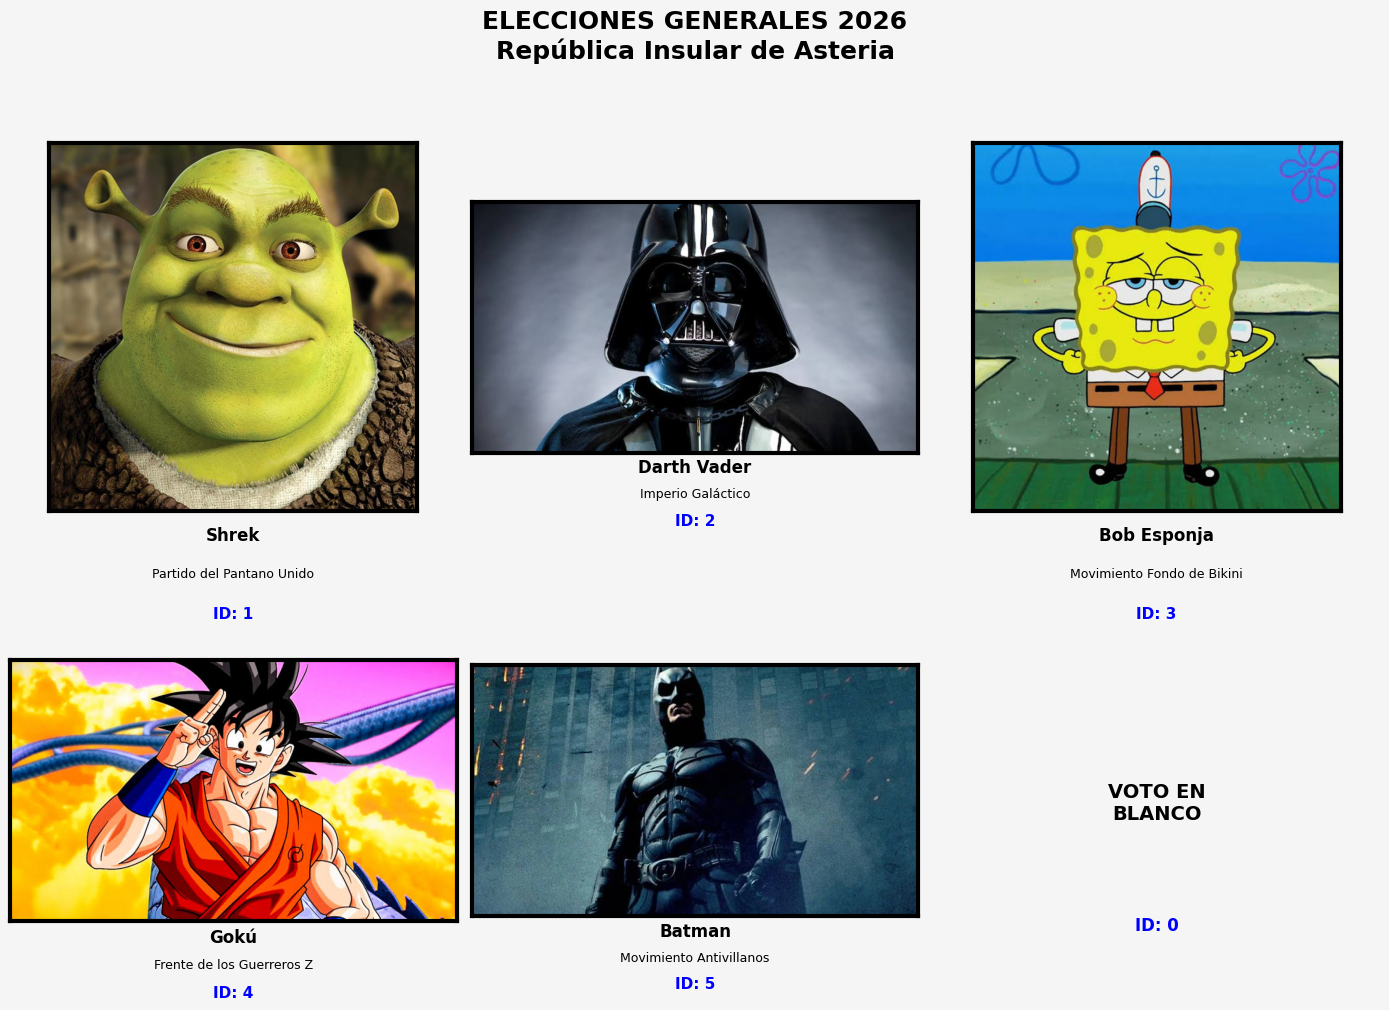

In [7]:
# =============================
# MOSTRAR TARJETÓN
# =============================


def mostrar_tarjeton():

    candidatos = pd.read_csv("candidatos.csv")
    candidatos = candidatos[candidatos["estado"] == "Activo"]

    if candidatos.empty:
        print("No hay candidatos activos.")
        return

    columnas = 3
    filas = (len(candidatos) + columnas - 1) // columnas

    fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(14,10),
    facecolor="#f5f5f5"
)
    axes = axes.flatten()

    fig.suptitle(
         "ELECCIONES GENERALES 2026\nRepública Insular de Asteria",
    fontsize=18,
    fontweight="bold"
    )

    for i, (_, candidato) in enumerate(candidatos.iterrows()):

      ax = axes[i]

      imagen = cv2.imread(candidato["imagen"])

      if imagen is None:
          ax.text(0.5,0.5,"Imagen\nno encontrada",
                  ha="center",va="center")
          ax.axis("off")
          continue

      imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

      # Mostrar imagen
      ax.imshow(imagen)

      # Quitar ejes
      ax.set_xticks([])
      ax.set_yticks([])

      # Marco tipo tarjeta
      for borde in ax.spines.values():
          borde.set_visible(True)
          borde.set_color("black")
          borde.set_linewidth(3)

      # Fondo blanco
      ax.set_facecolor("white")

      # Texto debajo
      ax.text(
          0.5,
          -0.08,
          candidato["nombre"],
          transform=ax.transAxes,
          ha="center",
          fontsize=12,
          fontweight="bold"
      )

      ax.text(
          0.5,
          -0.18,
          candidato["partido"],
          transform=ax.transAxes,
          ha="center",
          fontsize=9
      )

      ax.text(
          0.5,
          -0.29,
          f"ID: {candidato['id']}",
          transform=ax.transAxes,
          ha="center",
          fontsize=11,
          color="blue",
          fontweight="bold"
      )

    # Casilla para el voto en blanco
    if len(candidatos) < len(axes):

        ax = axes[len(candidatos)]

        ax.set_facecolor("white")

        ax.set_xticks([])
        ax.set_yticks([])

        for borde in ax.spines.values():
            borde.set_visible(True)
            borde.set_color("black")
            borde.set_linewidth(3)

        ax.text(
            0.5, 0.42,
            "VOTO EN\nBLANCO",
            transform=ax.transAxes,
            ha="center",
            fontsize=14,
            fontweight="bold"
        )

        ax.text(
            0.5, 0.12,
            "ID: 0",
            transform=ax.transAxes,
            ha="center",
            fontsize=12,
            color="blue",
            fontweight="bold"
        )

    # Ocultar cuadros sobrantes
    for j in range(len(candidatos), len(axes)):
        axes[j].axis("off")

    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()
    plt.close('all')

mostrar_tarjeton()